In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [3]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv('MicrosoftStock.csv')

In [5]:
df.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   str    
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   str    
dtypes: float64(4), int64(2), str(2)
memory usage: 96.0 KB


In [7]:
df.isnull().sum()

index     0
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [8]:
df.describe()

,index,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,390827.000000,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,363.586303,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,390198.000000,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,390512.500000,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,390827.000000,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,391141.500000,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,391456.000000,95.140000,96.070000,93.720000,95.010000,2.483542e+08


In [9]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [10]:
df.drop(columns=['index', 'Name'], inplace=True, errors='ignore')

In [11]:
df.interpolate(method='time', inplace=True)

,open,high,low,close,volume
date,,,,,
2013-02-08,27.35,27.710,27.3100,27.55,33318306
2013-02-11,27.65,27.920,27.5000,27.86,32247549
2013-02-12,27.88,28.000,27.7500,27.88,35990829
2013-02-13,27.93,28.110,27.8800,28.03,41715530
2013-02-14,27.92,28.060,27.8700,28.04,32663174
...,...,...,...,...,...
2018-02-01,94.79,96.070,93.5813,94.26,47227882
2018-02-02,93.64,93.970,91.5000,91.78,47867753
2018-02-05,90.56,93.240,88.0000,88.00,51031465


In [12]:
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()

In [13]:
rolling_std = df['close'].rolling(window=20).std()
df['BB_upper'] = df['SMA_20'] + (rolling_std * 2)
df['BB_lower'] = df['SMA_20'] - (rolling_std * 2)

In [14]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

In [15]:
df.dropna(inplace=True)

In [16]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (992, 10)
Testing data shape: (248, 10)


In [17]:
scaler = MinMaxScaler()
train_scaled_array = scaler.fit_transform(train_df)
test_scaled_array = scaler.transform(test_df)

In [18]:
train_scaled = pd.DataFrame(train_scaled_array, columns=train_df.columns, index=train_df.index)
test_scaled = pd.DataFrame(test_scaled_array, columns=test_df.columns, index=test_df.index)

In [19]:
train_scaled.head()

,open,high,low,close,volume,SMA_20,EMA_20,BB_upper,BB_lower,RSI_14
date,,,,,,,,,,
2013-03-08,0.010832,0.010011,0.008591,0.003429,0.121934,0.000000,0.000034,0.000576,0.011386,0.408862
2013-03-11,0.002642,0.000527,0.000805,0.000000,0.117600,0.000447,0.000000,0.000388,0.012498,0.373542
2013-03-12,0.000000,0.000000,0.000000,0.001055,0.128542,0.000517,0.000076,0.000449,0.012576,0.420098
2013-03-13,0.000793,0.001844,0.002953,0.001187,0.086202,0.000566,0.000157,0.000496,0.012626,0.522599
2013-03-14,0.004227,0.005532,0.007785,0.006990,0.197967,0.000712,0.000817,0.000850,0.012551,0.511681


In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

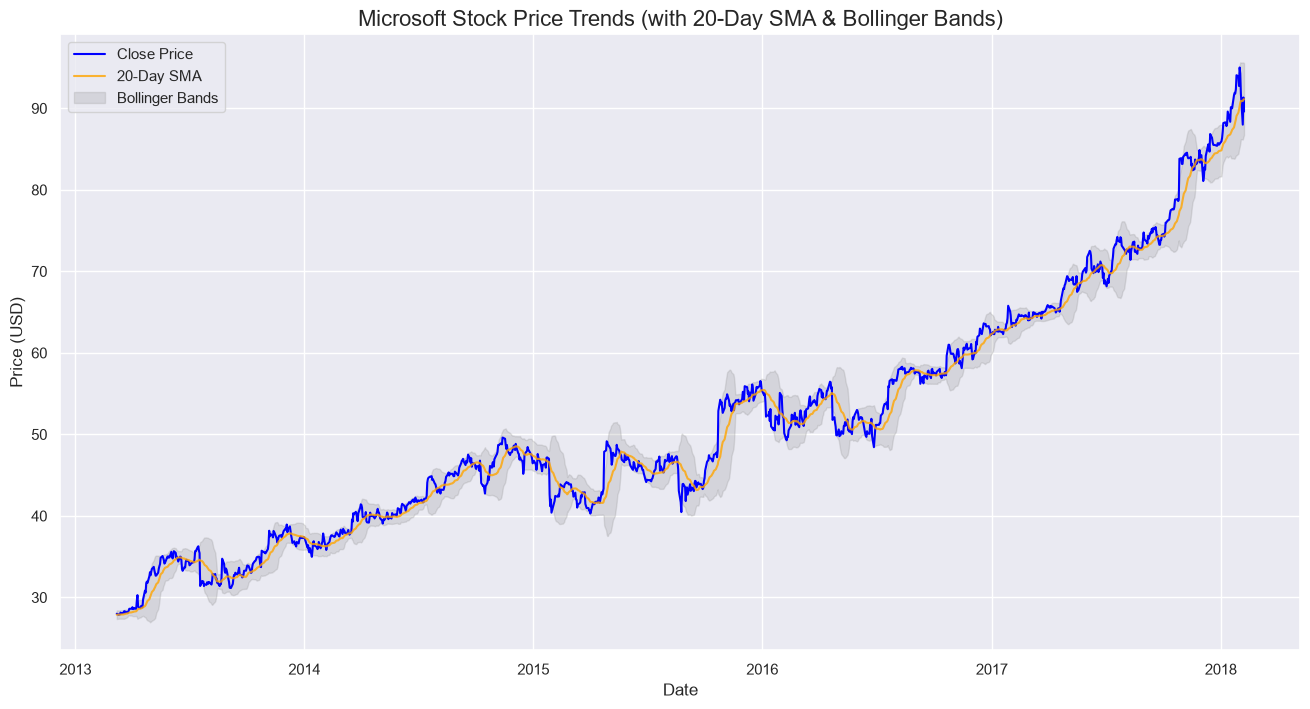

In [21]:
plt.figure(figsize=(16, 8))
plt.plot(df.index, df['close'], label='Close Price', color='blue', linewidth=1.5)
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='orange', alpha=0.8, linewidth=1.5)
plt.fill_between(df.index, df['BB_lower'], df['BB_upper'], color='gray', alpha=0.2, label='Bollinger Bands')

plt.title('Microsoft Stock Price Trends (with 20-Day SMA & Bollinger Bands)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.show()

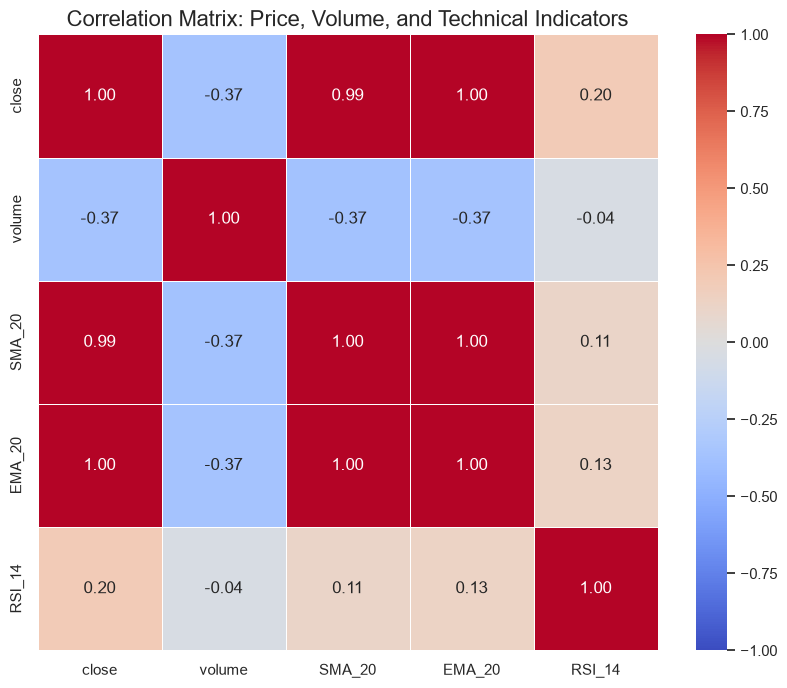

In [22]:
plt.figure(figsize=(10, 8))
correlation_cols = ['close', 'volume', 'SMA_20', 'EMA_20', 'RSI_14']
corr_matrix = df[correlation_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Price, Volume, and Technical Indicators', fontsize=16)
plt.show()


Performing Seasonal Decomposition...


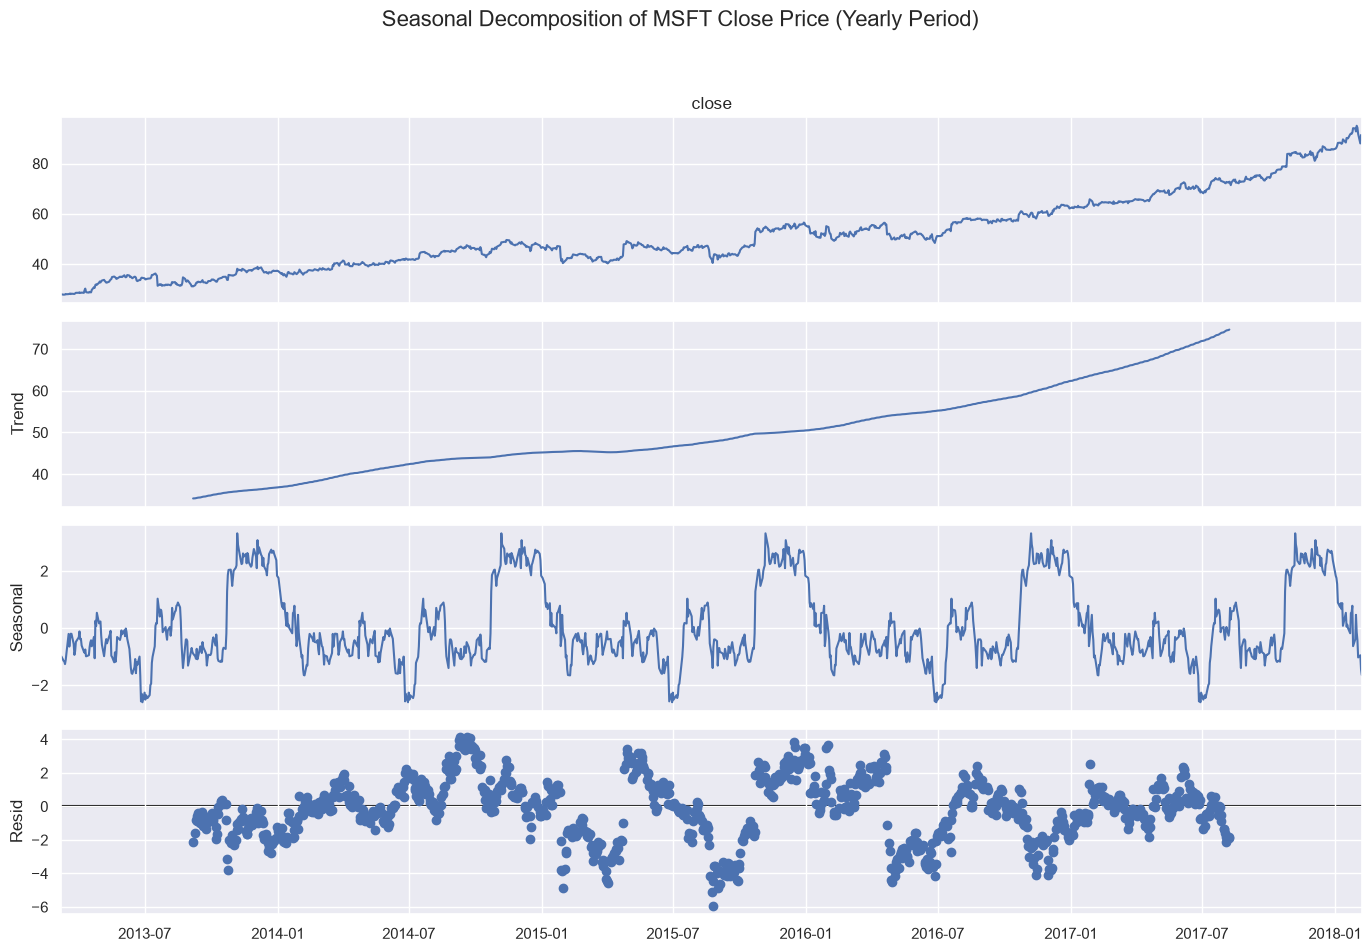

In [23]:
print("\nPerforming Seasonal Decomposition...")
decomposition = seasonal_decompose(df['close'], model='additive', period=252)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Seasonal Decomposition of MSFT Close Price (Yearly Period)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [25]:
def create_sequences(data, target_col_idx, look_back=60):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, :])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

In [26]:
close_idx = train_scaled.columns.get_loc('close')

look_back = 60
X_train_lstm, y_train = create_sequences(train_scaled.values, close_idx, look_back)
X_test_lstm, y_test = create_sequences(test_scaled.values, close_idx, look_back)

In [27]:
X_train_ml = X_train_lstm.reshape((X_train_lstm.shape[0], -1))
X_test_ml = X_test_lstm.reshape((X_test_lstm.shape[0], -1))

print(f"Data shape for LSTM: {X_train_lstm.shape}")
print(f"Data shape for ML models: {X_train_ml.shape}")

Data shape for LSTM: (932, 60, 10)
Data shape for ML models: (932, 600)


In [28]:
lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](600,)","[-0.06, 0.04,-0.02,..., 0.15,-0.03, 0.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.006902
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,600
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,440
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](600,)","[143.87, 28.92, 23.61,..., 0. , 0. , 0. ]"


In [29]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ml, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [30]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_ml, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
lstm_model = Sequential()

# First LSTM layer with Dropout regularization to prevent overfitting
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.2))

# Second LSTM layer
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))

# Output layer predicting the scaled 'close' price (1 continuous value)
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\aeman\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
history = lstm_model.fit(
    X_train_lstm, y_train, 
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test), 
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0429 - val_loss: 0.1487
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0087 - val_loss: 0.1357
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0065 - val_loss: 0.0689
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0050 - val_loss: 0.0649
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0052 - val_loss: 0.0466
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0047 - val_loss: 0.0342
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0041 - val_loss: 0.0310
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0043 - val_loss: 0.0280
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0037 - val_loss: 0.0362
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0041 - val_loss: 0.0119
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0040 - val_loss: 0.0332
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0

In [33]:
import yfinance as yf

In [34]:
lstm_predictions_scaled = lstm_model.predict(X_test_lstm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


In [35]:
close_idx = train_scaled.columns.get_loc('close')
num_features = train_scaled.shape[1]

In [36]:
dummy_pred = np.zeros((len(lstm_predictions_scaled), num_features))
dummy_pred[:, close_idx] = lstm_predictions_scaled[:, 0]
lstm_predictions = scaler.inverse_transform(dummy_pred)[:, close_idx]

In [37]:
dummy_actual = np.zeros((len(y_test), num_features))
dummy_actual[:, close_idx] = y_test
actual_prices = scaler.inverse_transform(dummy_actual)[:, close_idx]

In [38]:
mae = mean_absolute_error(actual_prices, lstm_predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, lstm_predictions))
r2 = r2_score(actual_prices, lstm_predictions)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): $3.63
Root Mean Squared Error (RMSE): $4.52
R2 Score: 0.6177


In [39]:
msft = yf.Ticker('MSFT')
msft_live = msft.history(period='100d')

In [40]:
if msft_live.index.tz is not None:
    msft_live.index = msft_live.index.tz_localize(None)

msft_live['SMA_20'] = msft_live['Close'].rolling(window=20).mean()
msft_live['EMA_20'] = msft_live['Close'].ewm(span=20, adjust=False).mean()

rolling_std_live = msft_live['Close'].rolling(window=20).std()
msft_live['BB_upper'] = msft_live['SMA_20'] + (rolling_std_live * 2)
msft_live['BB_lower'] = msft_live['SMA_20'] - (rolling_std_live * 2)

delta_live = msft_live['Close'].diff()
gain_live = delta_live.where(delta_live > 0, 0)
loss_live = -delta_live.where(delta_live < 0, 0)
avg_gain_live = gain_live.rolling(window=14).mean()
avg_loss_live = loss_live.rolling(window=14).mean()
rs_live = avg_gain_live / avg_loss_live
msft_live['RSI_14'] = 100 - (100 / (1 + rs_live))

In [41]:
msft_live.rename(columns={'Open':'open', 'High':'high', 'Low':'low', 'Close':'close', 'Volume':'volume'}, inplace=True)
msft_live.dropna(inplace=True)

In [42]:
msft_live = msft_live[train_scaled.columns]

In [43]:
#last_60_days = msft_live.tail(60)
#last_60_days_scaled = scaler.transform(last_60_days)

In [44]:
future_predictions_scaled = []
current_sequence = test_scaled.values[-look_back:].copy()

for _ in range(30):
    next_pred = lstm_model.predict(current_sequence.reshape(1, look_back, num_features), verbose=0)[0][0]
    future_predictions_scaled.append(next_pred)
    
    current_sequence = np.roll(current_sequence, -1, axis=0)
    current_sequence[-1, :] = current_sequence[-2, :] 
    current_sequence[-1, close_idx] = next_pred

dummy_future = np.zeros((30, num_features))
dummy_future[:, close_idx] = future_predictions_scaled
future_prices = scaler.inverse_transform(dummy_future)[:, close_idx]

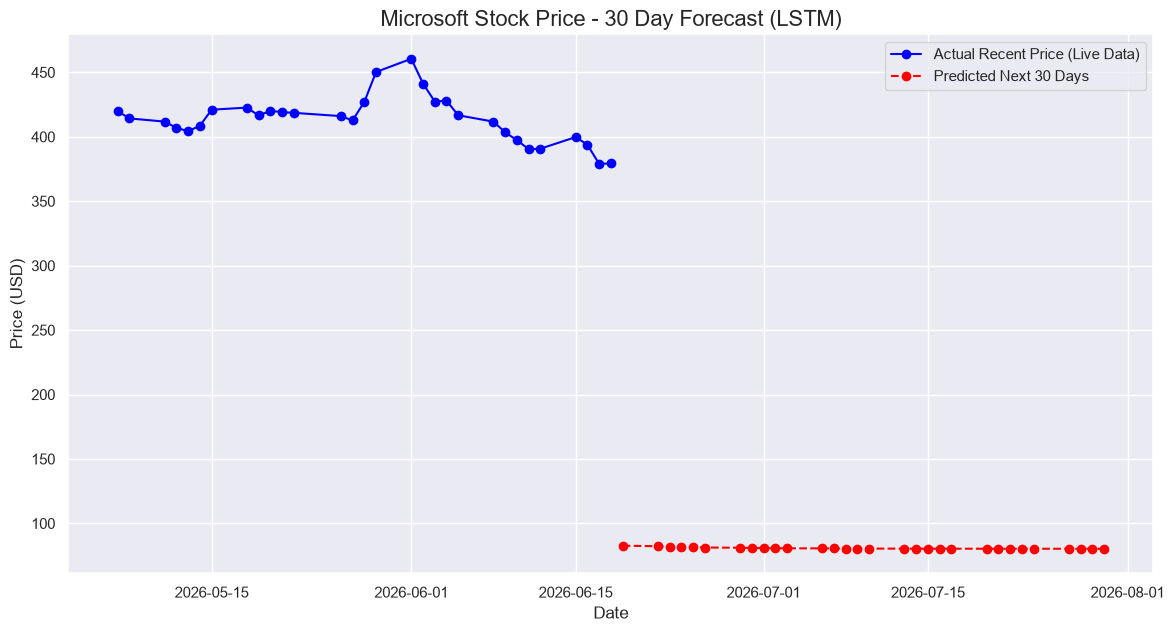

In [45]:
last_date = msft_live.index[-1]
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=30, freq='B')

plt.figure(figsize=(14, 7))
plt.plot(msft_live.index[-30:], msft_live['close'].tail(30), label='Actual Recent Price (Live Data)', color='blue', marker='o')
plt.plot(future_dates, future_prices, label='Predicted Next 30 Days', color='red', linestyle='dashed', marker='o')

plt.title('Microsoft Stock Price - 30 Day Forecast (LSTM)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()